# 第 9 章 · BPE 代码实验

[章节网页](../ch9.html)

## 运行内容

- 准备字符级词表
- 执行 merge 步骤
- 绘制 pair 频次

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备 BPE 语料，把每个词拆成字符序列。
corpus = ["low", "lower", "newest", "widest"]
vocab = Counter(tuple(word) + ("</w>",) for word in corpus)

def pair_counts(vocab):
    counts = Counter()
    for symbols, freq in vocab.items():
        for i in range(len(symbols) - 1):
            counts[(symbols[i], symbols[i + 1])] += freq
    return counts


def merge_pair(vocab, pair):
    merged = {}
    bigram = " ".join(pair)
    replacement = "".join(pair)
    for symbols, freq in vocab.items():
        text = " ".join(symbols)
        new_symbols = tuple(text.replace(bigram, replacement).split())
        merged[new_symbols] = freq
    return Counter(merged)


display(pd.DataFrame({"token序列": [" ".join(k) for k in vocab.keys()], "频次": list(vocab.values())}))

,token序列,频次
0,l o w </w>,1
1,l o w e r </w>,1
2,n e w e s t </w>,1
3,w i d e s t </w>,1


## 1. Merge 过程

In [3]:
# 连续执行若干次 merge，记录每轮最高频 pair。
bpe_rows = []
history = []
current_vocab = vocab.copy()

for step in range(1, 7):
    counts = pair_counts(current_vocab)
    best_pair, best_count = counts.most_common(1)[0]
    current_vocab = merge_pair(current_vocab, best_pair)
    state = [" ".join(symbols) for symbols in current_vocab.keys()]
    bpe_rows.append({
        "轮次": step,
        "合并pair": " + ".join(best_pair),
        "频次": best_count,
        "当前token序列": " | ".join(state),
    })
    history.append((best_pair, counts))

bpe_trace = pd.DataFrame(bpe_rows)
display(bpe_trace)

,轮次,合并pair,频次,当前token序列
0,1,l + o,2,lo w </w> | lo w e r </w> | n e w e s t </w> |...
1,2,lo + w,2,low </w> | low e r </w> | n e w e s t </w> | w...
2,3,e + s,2,low </w> | low e r </w> | n e w es t </w> | w ...
3,4,es + t,2,low </w> | low e r </w> | n e w est </w> | w i...
4,5,est + </w>,2,low </w> | low e r </w> | n e w est</w> | w i ...
5,6,low + </w>,1,low</w> | low e r </w> | n e w est</w> | w i d...


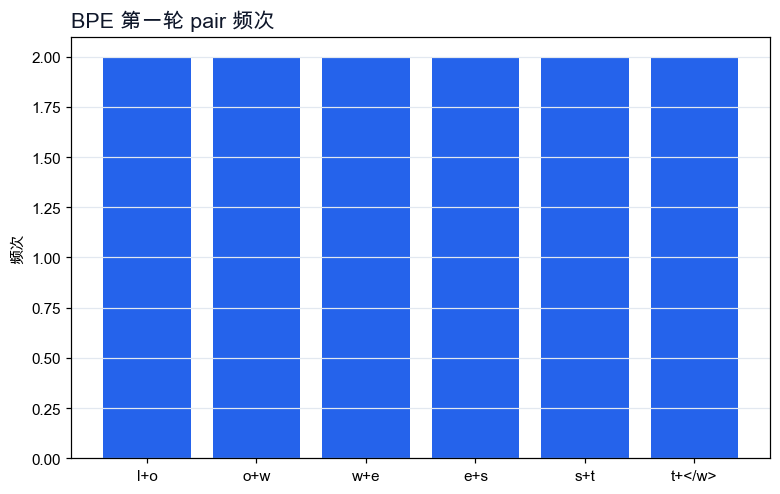

In [4]:
# 绘制第一轮 pair 频次。
first_counts = history[0][1]
top_pairs = first_counts.most_common(6)
labels = ["+".join(pair) for pair, _ in top_pairs]
values = [count for _, count in top_pairs]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.bar(labels, values, color="#2563eb")
ax.set_title("BPE 第一轮 pair 频次", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_ylabel("频次")
ax.grid(True, axis="y", color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()